# Classification Workflow: RDKit + Morgan FPs + Pre‑Reaction Metadata


# 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import shap
import pingouin as pg
import importlib
import model_comparison

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, AllChem

from model_comparison import make_boxplots_parametric, make_mcs_plot_grid, make_ci_plot_grid, make_normality_diagnostic

importlib.reload(model_comparison)

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.metrics import average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from IPython.display import display
from scipy.stats import shapiro, levene
import statsmodels.api as sm


# Comparative analysis imports
from scipy.special import ndtr
from scipy.stats import ttest_rel, wilcoxon, norm

# Seeds and bootstrap settings
SEEDS = [37, 42, 53, 69]
N_BOOT = 1000

c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Load & Prepare Data

In [2]:
DATA_PATH = "M:/EPSRC Internship 2025/Project/Data/Classification Model/epimerisation_data_clean.csv"
df = pd.read_csv(DATA_PATH, usecols=[
    'epimerisation','smilesstarting_material',
    'conditions','reaction_class','substrate_class',
    'derivative_notes','specific_reagents',
    'solvent_1','solvent_2','temperature_C','reaction_time_h'
]).rename(columns={'smilesstarting_material':'smi_start'})

y = df['epimerisation'].astype(int).values

# 3. Compute RDKit Descriptors

In [3]:
def compute_rdkit_descriptors(smiles, prefix):
    names = [f"{prefix}_{n}" for n,_ in Descriptors._descList]
    vals = []
    for smi in smiles:
        m = Chem.MolFromSmiles(smi)
        vals.append([f(m) if m else np.nan for _,f in Descriptors._descList])
    return pd.DataFrame(vals, columns=names)

rdkit_df = compute_rdkit_descriptors(df['smi_start'], 'rdkit')

# 4. Compute 1024‑bit Morgan Fingerprints + Density

In [4]:
def compute_morgan(smiles, radius=2, n_bits=1024, prefix='morgan'):
    fps, dens = [], []
    for smi in smiles:
        m = Chem.MolFromSmiles(smi)
        if m:
            fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits)
            arr = np.zeros((n_bits,), dtype=int)
            DataStructs.ConvertToNumpyArray(fp, arr)
            fps.append(arr)
            dens.append(arr.sum()/n_bits)
        else:
            fps.append(np.full((n_bits,), np.nan))
            dens.append(np.nan)
    cols = [f"{prefix}_bit_{i}" for i in range(n_bits)]
    df_bits = pd.DataFrame(fps, columns=cols)
    df_bits[f"{prefix}_density"] = dens
    return df_bits

morgan_df = compute_morgan(df['smi_start'], radius=2, n_bits=1024, prefix='morgan')

[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerator
[15:00:55] DEPRECATION WARNING: please use MorganGenerat

# 5. Process Pre‑Reaction Metadata

In [5]:
meta = df[[
    'conditions','reaction_class','substrate_class',
    'derivative_notes','specific_reagents',
    'solvent_1','solvent_2'
]].fillna('Missing')
meta_cat = pd.get_dummies(meta, drop_first=False)
meta_num = df[['temperature_C','reaction_time_h']].copy()
meta_num.fillna(meta_num.mean(), inplace=True)
meta_df = pd.concat([meta_cat, meta_num], axis=1)

# 6. Combine & Clean

In [6]:
X = pd.concat([rdkit_df, morgan_df, meta_df], axis=1)
mask = X.notna().all(axis=1)
X = X[mask].reset_index(drop=True)
y = y[mask]


# 7. Train/Test Split

In [7]:
SEED = 42  # or pick any value from SEEDS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)


# 8. Pipeline + Hyperparameter Tuning

In [8]:
feat_names = X.columns.tolist()

class CorrFilter(BaseEstimator, TransformerMixin):
    def __init__(self, thresh=0.9, feature_names=None):
        self.thresh = thresh
        self.feature_names = feature_names
    def fit(self, X, y=None):
        C = pd.DataFrame(X, columns=self.feature_names).corr().abs()
        U = C.where(np.triu(np.ones(C.shape),1).astype(bool))
        drop = [c for c in U.columns if any(U[c]>self.thresh)]
        self.keep = [i for i,f in enumerate(self.feature_names) if f not in drop]
        return self
    def transform(self, X): return X[:,self.keep]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
pipe = ImbPipeline([
    ('imp', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler()),
    ('corr', CorrFilter(thresh=0.9, feature_names=feat_names)),
    ('smote', SMOTE(random_state=SEED)),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=SEED))
])
param_dist = {
    'clf__n_estimators':[100,200,300], 'clf__max_depth':[None,10,20],
    'clf__min_samples_split':[2,5,10]
}
rs = RandomizedSearchCV(pipe, param_dist, n_iter=20,
                        scoring='precision', cv=cv,
                        random_state=SEED, n_jobs=-1)
rs.fit(X_train, y_train)
best = rs.best_estimator_


c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


# 9. Test Predictions & Metrics

In [9]:
# 4) Compute per-fold cross-validated metrics on the training set
cv_records = []
X_train_arr = X_train.values
y_train_arr = y_train
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    # clone and fit pipeline on this fold
    fold_pipe = clone(best)
    X_tr_fold, y_tr_fold = X_train_arr[train_idx], y_train_arr[train_idx]
    X_val_fold, y_val_fold = X_train_arr[val_idx],   y_train_arr[val_idx]
    fold_pipe.fit(X_tr_fold, y_tr_fold)
    # predict on validation fold
    y_pred_fold  = fold_pipe.predict(X_val_fold)
    y_proba_fold = fold_pipe.predict_proba(X_val_fold)[:,1]
    # record metrics
    cv_records.append({
        'fold':    fold_idx,
        'MCC':     matthews_corrcoef   (y_val_fold, y_pred_fold),
        'ROC AUC': roc_auc_score       (y_val_fold, y_proba_fold),
        'PR AUC':  average_precision_score(y_val_fold, y_proba_fold)
    })
cv_metrics_df = pd.DataFrame(cv_records)
print("=== Cross-Validated Fold Metrics ===")
display(cv_metrics_df.round(3))

# 5) Now predict on held-out test set
y_test_pred  = best.predict(X_test)
y_test_proba = best.predict_proba(X_test)[:,1]

# 6) Compute test metrics
test_metrics = {
    "Accuracy":  accuracy_score    (y_test, y_test_pred),
    "Precision": precision_score   (y_test, y_test_pred),
    "Recall":    recall_score      (y_test, y_test_pred),
    "F1":        f1_score          (y_test, y_test_pred),
    "ROC AUC":   roc_auc_score     (y_test, y_test_proba),
    "MCC":       matthews_corrcoef(y_test, y_test_pred)
}
cm = confusion_matrix(y_test, y_test_pred)

print("\n=== TEST SET METRICS ===")
print(pd.DataFrame(test_metrics, index=["Value"]).T.round(3))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", cm)

c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\hllpacke\.conda\

=== Cross-Validated Fold Metrics ===


,fold,MCC,ROC AUC,PR AUC
0,0,0.775,1.000,1.000
1,1,0.542,0.875,0.935
2,2,0.770,1.000,1.000
3,3,0.671,0.889,0.977
4,4,0.389,0.944,0.989



=== TEST SET METRICS ===
           Value
Accuracy   0.933
Precision  0.923
Recall     1.000
F1         0.960
ROC AUC    0.944
MCC        0.784

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.92      1.00      0.96        12

    accuracy                           0.93        15
   macro avg       0.96      0.83      0.88        15
weighted avg       0.94      0.93      0.93        15

Confusion Matrix:
 [[ 2  1]
 [ 0 12]]


In [10]:
# --- 1) Extract and label your basic‐features CV metrics ---
# Assume `cv_metrics_df` holds your per‐fold metrics for the 1024‐bit (basic) pipeline,
# and has columns ['bits','fold','MCC','ROC AUC','PR AUC'].

# Filter out only the basic‐features (1024‐bit) runs and drop the bits column:
meta_cv_df = cv_metrics_df.copy()

# Add a column to label this as the basic CV model:
meta_cv_df["model"] = "meta"

# Reorder so 'model' and 'fold' come first
cols = ["model", "fold"] + [c for c in meta_cv_df.columns if c not in ("model", "fold")]
meta_cv_df = meta_cv_df[cols]

# 1a) Inspect
print("Meta CV pipeline fold‐metrics:")
display(meta_cv_df.round(3))

# --- 2) Save to pickle ---
out_file = "meta_cv_metrics.pkl"
meta_cv_df.to_pickle(out_file)
print(f"✅ Saved basic‐features CV metrics to {out_file!r}")

# --- 3) (Later, in any notebook) you can reload via: ---
# import pandas as pd
# loaded_basic_cv = pd.read_pickle("basic_cv_metrics.pkl")
# display(loaded_basic_cv)


Meta CV pipeline fold‐metrics:


,model,fold,MCC,ROC AUC,PR AUC
0,meta,0,0.775,1.000,1.000
1,meta,1,0.542,0.875,0.935
2,meta,2,0.770,1.000,1.000
3,meta,3,0.671,0.889,0.977
4,meta,4,0.389,0.944,0.989


✅ Saved basic‐features CV metrics to 'meta_cv_metrics.pkl'


# 10. Y‑Randomization (50 permutes)

In [11]:
# 10) Y-randomization with cross-validation on TRAINING set (50 shuffles)

# define a scorer for MCC
mcc_scorer = make_scorer(matthews_corrcoef)

# we'll reuse the same pipeline & cv scheme you defined above
rand_res = {m: [] for m in test_metrics}

for i in range(50):
    # shuffle the training labels
    y_shuf = np.random.permutation(y_train)
    # run cross‐validation on X_train / y_shuf
    cv_results = cross_validate(
        best,                    # your tuned pipeline from above
        X_train, 
        y_shuf,
        cv=cv,                   # same StratifiedKFold
        scoring={
            "Accuracy": "accuracy",
            "Precision": "precision",
            "Recall": "recall",
            "F1": "f1",
            "ROC AUC": "roc_auc",
            "MCC": mcc_scorer
        },
        return_train_score=False,
        n_jobs=-1
    )
    # record the mean of each fold‐score
    rand_res["Accuracy"].append(cv_results["test_Accuracy"].mean())
    rand_res["Precision"].append(cv_results["test_Precision"].mean())
    rand_res["Recall"].append(cv_results["test_Recall"].mean())
    rand_res["F1"].append(cv_results["test_F1"].mean())
    rand_res["ROC AUC"].append(cv_results["test_ROC AUC"].mean())
    rand_res["MCC"].append(cv_results["test_MCC"].mean())

# summarize
rand_summary = []
for m, vals in rand_res.items():
    arr = np.array(vals)
    mu, sd = arr.mean(), arr.std(ddof=1)
    observed = test_metrics[m]  # Use the correct variable here
    z = (observed - mu) / sd if sd > 0 else np.nan
    p = 1 - ndtr(z) if not np.isnan(z) else np.nan
    rand_summary.append({
        "Metric": m,
        "Real": round(observed, 3),
        "Rand Mean±SD": f"{mu:.3f}±{sd:.3f}",
        "Z-score": round(z, 3) if not np.isnan(z) else np.nan,
        "p-value": round(p, 3) if not np.isnan(p) else np.nan
    })

print("\n=== Y-RANDOMIZATION (Test) ===")
display(pd.DataFrame(rand_summary).set_index("Metric"))



=== Y-RANDOMIZATION (Test) ===


,Real,Rand Mean±SD,Z-score,p-value
Metric,,,,
Accuracy,0.933,0.671±0.062,4.268,0.000
Precision,0.923,0.773±0.038,3.943,0.000
Recall,1.000,0.809±0.056,3.410,0.000
F1,0.960,0.785±0.043,4.033,0.000
ROC AUC,0.944,0.504±0.135,3.265,0.001
MCC,0.784,0.029±0.179,4.221,0.000


In [12]:
rand_res={m:[] for m in test_metrics}
for _ in range(50):
    ys = np.random.permutation(y_test)
    p = best.predict(X_test)
    pr = best.predict_proba(X_test)[:,1]
    rand_res['Accuracy'].append(accuracy_score(ys,p))
    rand_res['Precision'].append(precision_score(ys,p,zero_division=0))
    rand_res['Recall'].append(recall_score(ys,p,zero_division=0))
    rand_res['F1'].append(f1_score(ys,p,zero_division=0))
    rand_res['ROC AUC'].append(roc_auc_score(ys,pr))
    rand_res['MCC'].append(matthews_corrcoef(ys,p))
summary = []
for m, vals in rand_res.items():
    arr = np.array(vals)
    rand_mean = arr.mean()
    rand_std = arr.std(ddof=1)
    observed = test_metrics[m]
    z = (observed - rand_mean) / rand_std if rand_std > 0 else np.nan
    p = 1 - ndtr(z) if not np.isnan(z) else np.nan
    summary.append({'Metric': m, 'Real': test_metrics[m], 'Rand μ±σ': f"{rand_mean:.3f}±{rand_std:.3f}", 'p-value': round(p, 3)})
print(pd.DataFrame(summary).set_index('Metric'))

               Real      Rand μ±σ  p-value
Metric                                    
Accuracy   0.933333   0.717±0.071    0.001
Precision  0.923077   0.798±0.041    0.001
Recall     1.000000   0.865±0.044    0.001
F1         0.960000   0.830±0.042    0.001
ROC AUC    0.944444   0.491±0.178    0.005
MCC        0.784465  -0.010±0.260    0.001


# 11. Feature Importances (RF & SHAP)

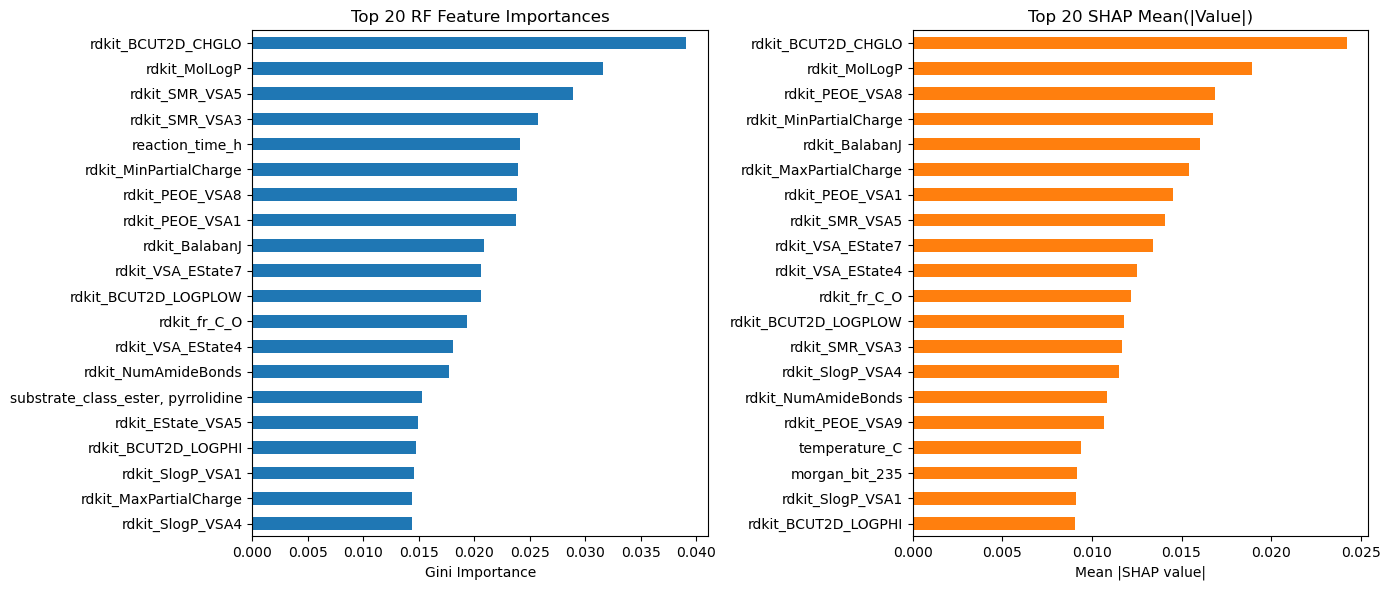

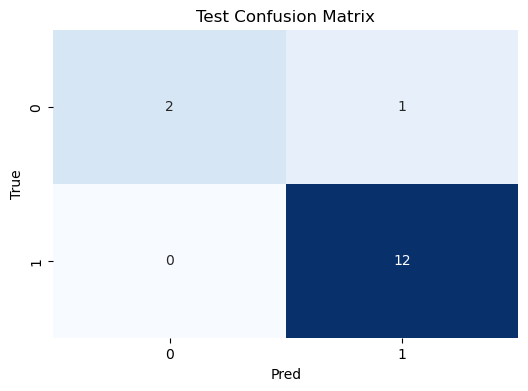

C:\Users\hllpacke\AppData\Local\Temp\ipykernel_18968\139861538.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  trapz_ap = np.trapz(prec[::-1], rec[::-1])


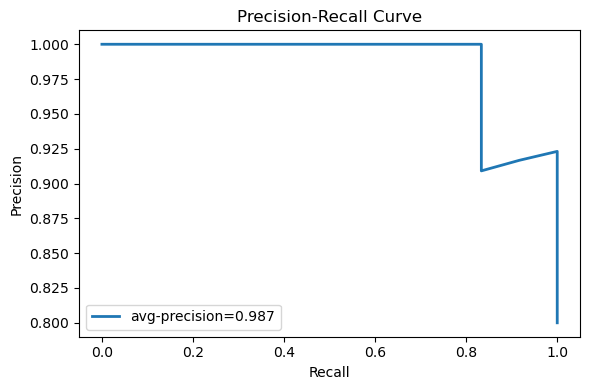

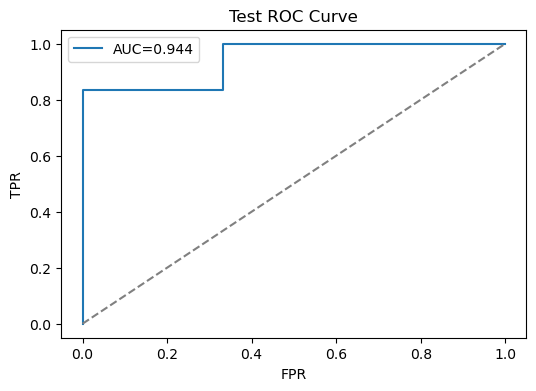

In [16]:
# RF & SHAP Feature Importances Side-by-Side 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# RF importances (post-corr filter)
keep_idx    = best.named_steps["corr"].keep
final_feats = np.array(feat_names)[keep_idx]  # Only the features kept after correlation filter
rf_imp      = best.named_steps["clf"].feature_importances_
# Ensure rf_imp and final_feats have the same length
assert len(rf_imp) == len(final_feats), f"rf_imp ({len(rf_imp)}) and final_feats ({len(final_feats)}) length mismatch"
rf_series   = pd.Series(rf_imp, index=final_feats).sort_values(ascending=False)

# SHAP importances
#  a) Transform TEST set through the pipeline up to the classifier
X_imp = best.named_steps["imp"].transform(X_test)
X_sc  = best.named_steps["scale"].transform(X_imp)
X_cf  = best.named_steps["corr"].transform(X_sc)

#  b) Compute SHAP values
explainer = shap.TreeExplainer(best.named_steps["clf"])
shap_vals = explainer.shap_values(X_cf)

#  c) Extract the “positive‐class” SHAP array in a robust way
# For binary classification, shap_vals is a list of 2 arrays (n_samples, n_features)
if isinstance(shap_vals, list):
    arr = shap_vals[1]  # positive class
else:
    arr = shap_vals

# Ensure arr shape matches (n_samples, n_features)
if arr.shape[1] != len(final_feats):
    raise ValueError(f"SHAP values shape {arr.shape} does not match number of features {len(final_feats)}")

#  d) Mean(|SHAP|) across samples
# If shap_imp is 2D (n_features, 2), reduce to 1D by averaging over the last axis
shap_imp = np.abs(arr).mean(axis=0)
if shap_imp.ndim == 2:
    shap_imp = shap_imp.mean(axis=1)
shap_series = pd.Series(shap_imp, index=final_feats).sort_values(ascending=False)

# Plot them side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_series.head(20).plot(
    kind="barh", ax=axes[0], color="C0"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 20 RF Feature Importances")
axes[0].set_xlabel("Gini Importance")

shap_series.head(20).plot(
    kind="barh", ax=axes[1], color="C1"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 20 SHAP Mean(|Value|)")
axes[1].set_xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.show()


# Confusion matrix, ROC curve & PR curve
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Test Confusion Matrix"); plt.xlabel("Pred"); plt.ylabel("True")
plt.show()

# Precision‐Recall curve
prec, rec, pr_thresh = precision_recall_curve(y_test, y_test_proba)
# 1) Official average‐precision
ap = average_precision_score(y_test, y_test_proba)
# 2) (Optional) trapezoidal area — must reverse to get positive area
trapz_ap = np.trapz(prec[::-1], rec[::-1])

plt.figure(figsize=(6,4))
plt.plot(rec, prec, lw=2, label=f"avg-precision={ap:.3f}")
# plt.plot(rec, prec, lw=2, label=f"trapz(AP)={trapz_ap:.3f}")  # if you prefer
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={test_metrics['ROC AUC']:.3f}")
plt.plot([0,1],[0,1],'--',c='gray')
plt.title("Test ROC Curve"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
plt.show()

In [17]:
import pandas as pd

# 1) Load the per‐fold meta‐model metrics
meta_df = pd.read_pickle("meta_cv_metrics.pkl")
meta_df["model"] = "meta"

# 2) Load the basic‐model CV results
basic_df = pd.read_pickle("basic_cv_metrics.pkl")
basic_df["model"] = "basic"

# 3) (Optional) ensure 'model' and 'fold' are the first two columns
def reorder(df):
    cols = ["model", "fold"] + [c for c in df.columns if c not in ("model", "fold")]
    return df[cols]

meta_df = reorder(meta_df)
basic_df = reorder(basic_df)

# 4) Concatenate and write to CSV
combined = pd.concat([basic_df, meta_df], ignore_index=True)
combined.to_csv("combined_model_metrics.csv", index=False)

print(f"✅ Saved combined CSV with {combined.shape[0]} rows and {combined.shape[1]} columns to 'combined_model_metrics.csv'")


✅ Saved combined CSV with 10 rows and 5 columns to 'combined_model_metrics.csv'


# Basic vs Pre-reaction Metadata Feature Comparison

# 12. Homogeneity of Variances Assumption

In [ ]:

# Map lowercase metric names to DataFrame columns
metric_map = {
    'mcc': 'MCC',
    'roc_auc': 'ROC AUC',
    'pr_auc': 'PR AUC'
}
metric_ls = ['mcc', 'roc_auc', 'pr_auc']
for metric in metric_ls:
    col = metric_map[metric]
    groups = [group[col] for name, group in combined.groupby('model')]
    stat, pvalue = levene(*groups)
    print(f"Levene test for {col}: p-value = {pvalue:.4f}")



Levene test for MCC: p-value = 0.3137
Levene test for ROC AUC: p-value = 0.5981
Levene test for PR AUC: p-value = 0.6365


In [22]:
# Ensure metric_ls and metric_map are defined
# metric_ls = ['mcc', 'roc_auc', 'pr_auc']
# metric_map = {'mcc': 'MCC', 'roc_auc': 'ROC AUC', 'pr_auc': 'PR AUC'}

cols = [metric_map[m] for m in metric_ls]
variances_by_model = combined.groupby('model')[cols].var()
max_fold_diff = variances_by_model.max() / variances_by_model.min()
print(max_fold_diff)

MCC        3.433809
ROC AUC    2.021978
PR AUC     1.830770
dtype: float64


# 13. Normality Assumption 

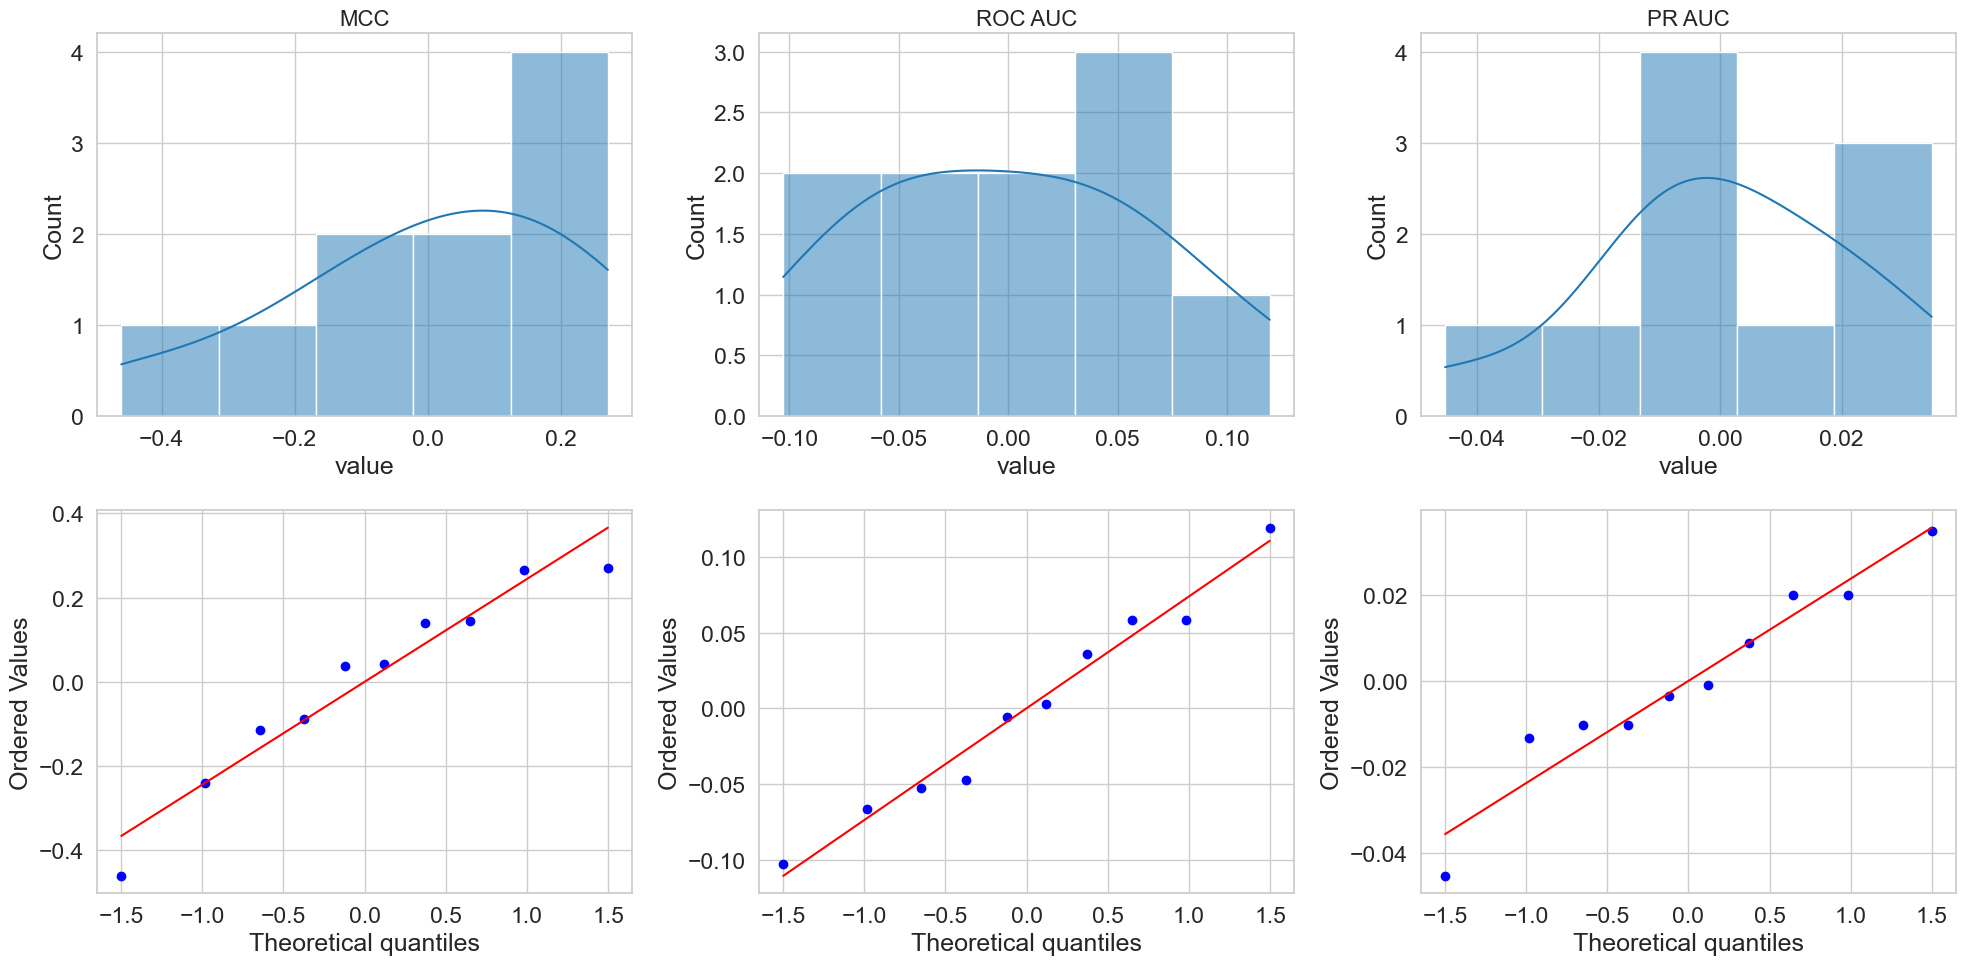

In [23]:
metric_ls = ['mcc', 'roc_auc', 'pr_auc']

# Use metric_map to access the correct DataFrame columns
# If make_normality_diagnostic expects the actual column names, map them:
metric_map = {'mcc': 'MCC', 'roc_auc': 'ROC AUC', 'pr_auc': 'PR AUC'}
cols = [metric_map[m] for m in metric_ls]

# Add a 'method' column if it does not exist (for compatibility)
if 'method' not in combined.columns:
	combined['method'] = combined['model']

# Add dummy 'cv_cycle' and 'split' columns if missing
for col in ['cv_cycle', 'split']:
	if col not in combined.columns:
		combined[col] = 0  # or use np.nan or a suitable default

make_normality_diagnostic(combined, cols)

# 14. Repeated measures ANOVA

Aggregated DataFrame columns: ['cv_cycle', 'method', 'MCC', 'ROC AUC', 'PR AUC']
Rows per cv_cycle×method:
cv_cycle  method
0         basic     1
          meta      1
1         basic     1
          meta      1
2         basic     1
          meta      1
3         basic     1
          meta      1
4         basic     1
          meta      1
dtype: int64


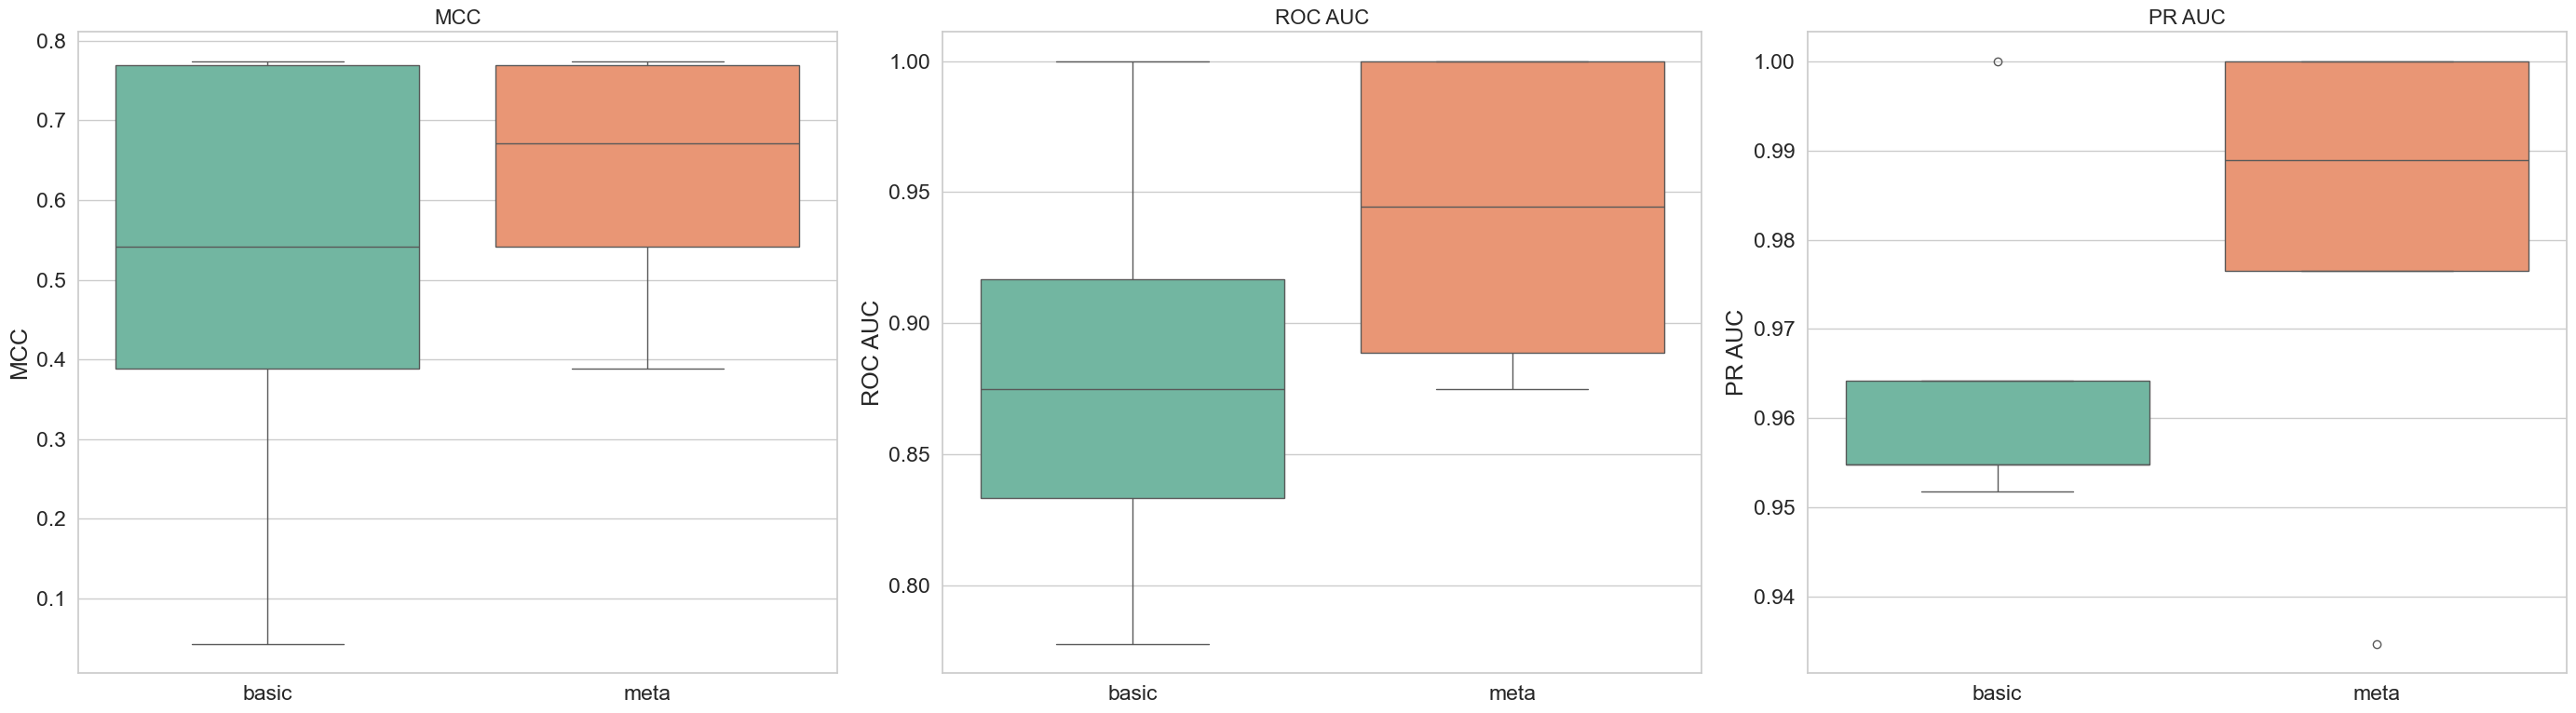

In [24]:
# %%  ▶ Aggregate + rename so that AnovaRM sees exactly one (cv_cycle × method) per row
import pandas as pd
import matplotlib.pyplot as plt
import model_comparison

# reload combined if needed; or use your df in memory
combined = pd.read_csv("combined_model_metrics.csv")

# map from lowercase keys → human titles
metric_ls  = ['mcc','roc_auc','pr_auc']
metric_map = {'mcc': 'MCC', 'roc_auc': 'ROC AUC', 'pr_auc': 'PR AUC'}
cols       = [metric_map[m] for m in metric_ls]

# 1) average duplicates
agg = (
    combined
    .groupby(['fold','model'])[cols]
    .mean()
    .reset_index()
)

# 2) rename to what the stats routines expect
agg = agg.rename(columns={
    'fold': 'cv_cycle',
    'model': 'method'
})

print("Aggregated DataFrame columns:", agg.columns.tolist())
print("Rows per cv_cycle×method:")
print(agg.groupby(['cv_cycle','method']).size())

# 3) call your boxplot function
model_comparison.make_boxplots_parametric(agg, cols)

# 4) grab the current figure & axes and set titles
fig = plt.gcf()
axes = fig.axes  # list of Axes in the order they were drawn
for ax, title in zip(axes, cols):
    ax.set_title(title, fontsize=16)

fig.tight_layout()


# 15 Post-Hoc Analysis to Examine Differences Between Methods (MCS Plots)

In [25]:
import importlib
import model_comparison
importlib.reload(model_comparison)



<module 'model_comparison' from 'm:\\EPSRC Internship 2025\\Project\\Data\\Classification Model\\Comparisons\\Polaris\\Final Models\\model_comparison.py'>

Columns: ['model', 'cv_cycle', 'mcc', 'roc_auc', 'pr_auc']


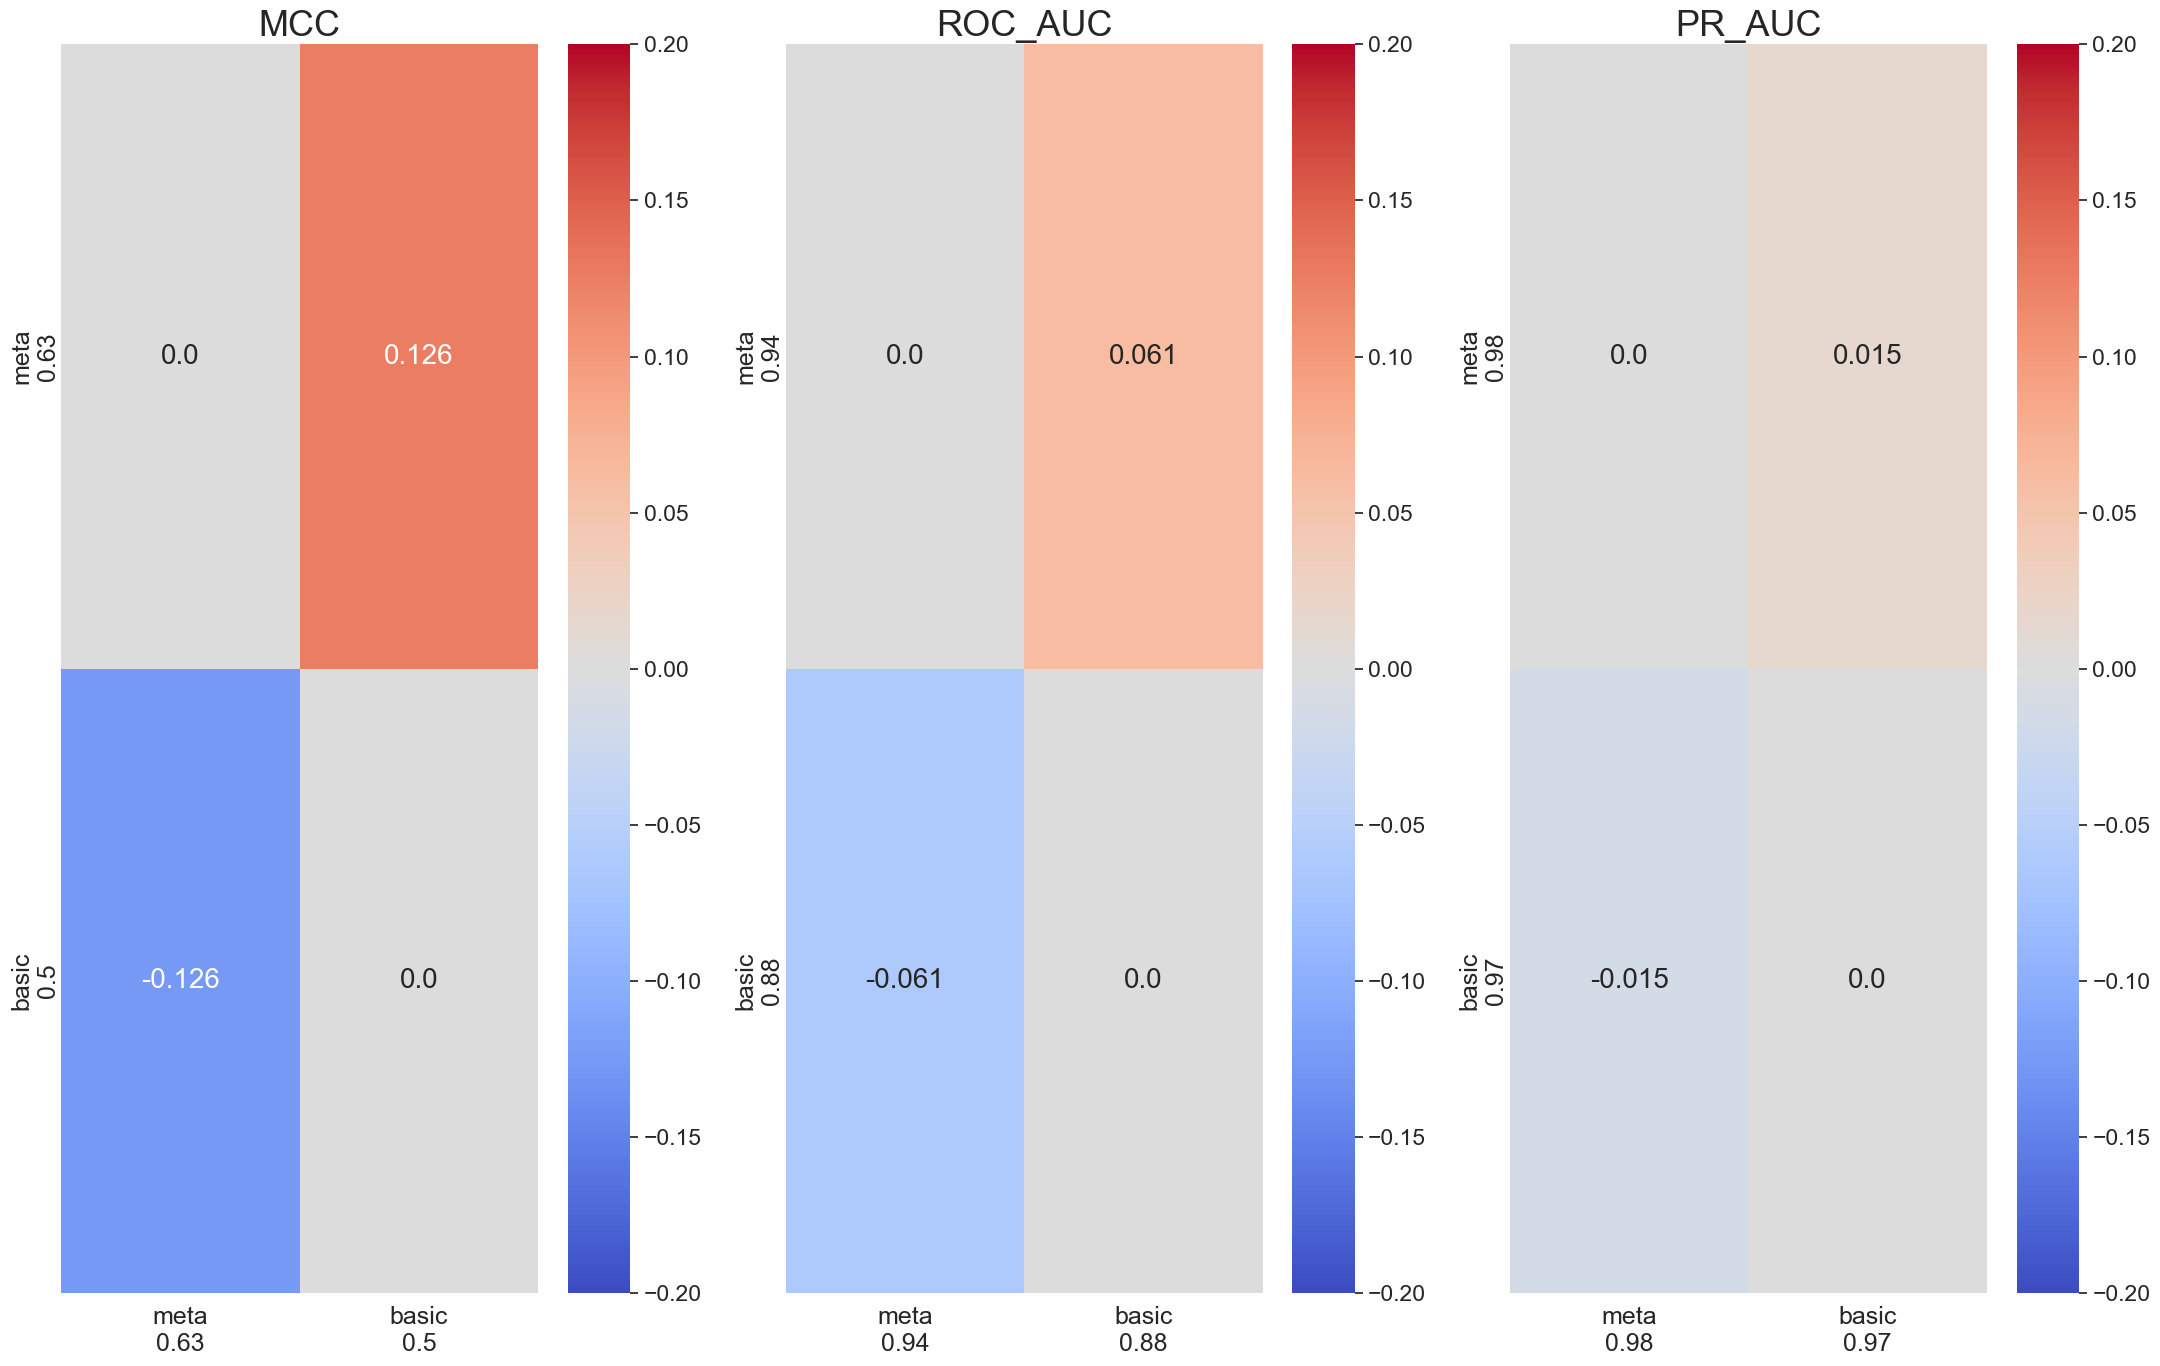

In [26]:
# %%  Prepare `combined` for make_mcs_plot_grid
import pandas as pd
import model_comparison

# 1) (Re)load and normalize column names
combined = pd.read_csv("combined_model_metrics.csv") \
    .rename(columns={
        "fold": "cv_cycle",      # what rm_tukey_hsd/AnovaRM expects
        "MCC":  "mcc",
        "ROC AUC": "roc_auc",
        "PR AUC":  "pr_auc"
    })

# 2) Confirm
print("Columns:", combined.columns.tolist())

# 3) Define your metrics & dicts
metric_ls = ["mcc", "roc_auc", "pr_auc"]
effect_dict = {"roc_auc": .1, "pr_auc": .1, "mcc": .1}
direction_dict = {"roc_auc":"maximize", "pr_auc":"maximize", "mcc":"maximize"}

# 4) Call the plot routine
model_comparison.make_mcs_plot_grid(
    combined,
    metric_ls,
    group_col="model",
    effect_dict=effect_dict,
    direction_dict=direction_dict,
    figsize=(22, 14),
    cell_text_size=20,
    axis_text_size=18,
    title_text_size=26,
    show_diff=True,
    sort_axes=True
)


# 16. Difference in Confidence Intervals  

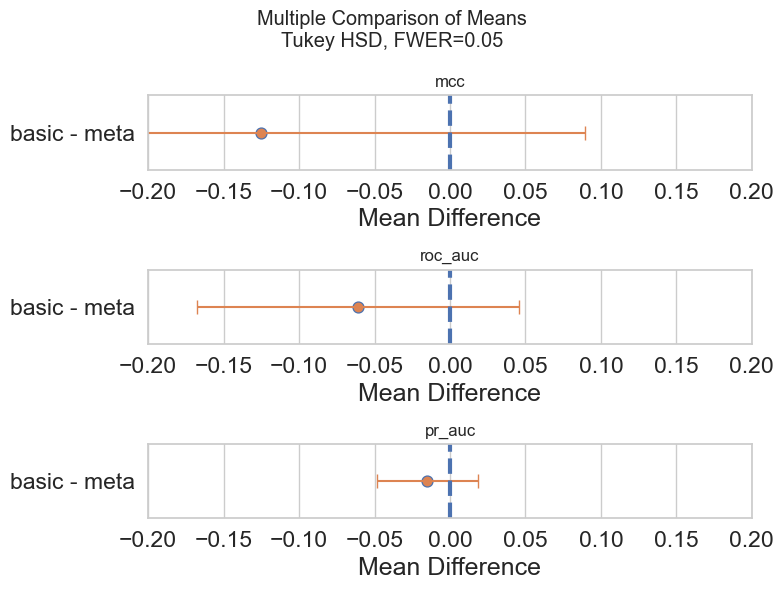

In [27]:
make_ci_plot_grid(combined, metric_ls, "model")

# 17. Violin Plots

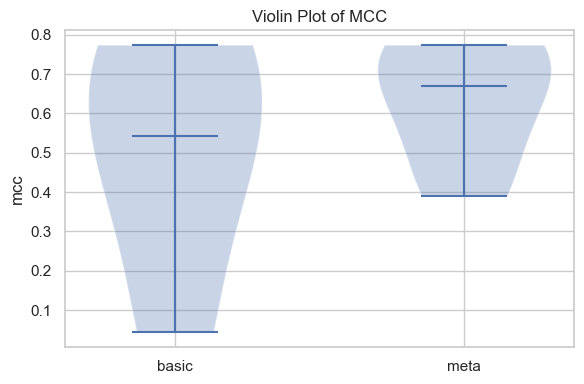

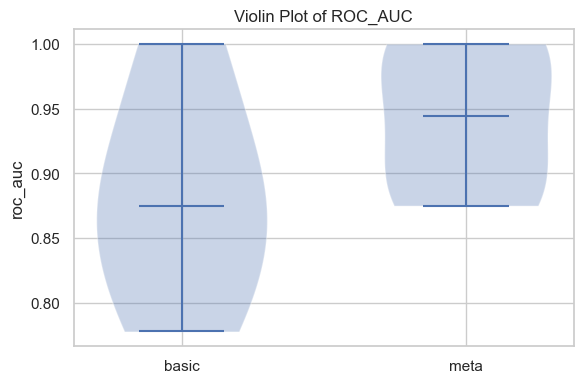

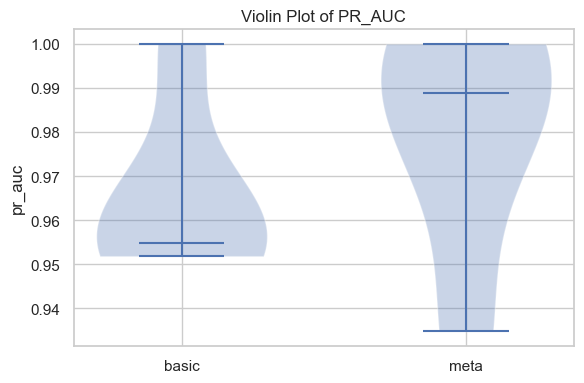

In [34]:
# %%  Violin plots for cross-validated metrics (fixed column names)
import matplotlib.pyplot as plt

# your metric keys (and these must match the column names in `combined`)
metric_ls = ['mcc', 'roc_auc', 'pr_auc']

for metric in metric_ls:
    # no mapping needed if your DataFrame columns are lowercase
    # pull out the two groups by 'model'
    d_basic = combined.loc[combined['model'] == 'basic', metric].values
    d_meta  = combined.loc[combined['model'] == 'meta',  metric].values

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.violinplot(
        [d_basic, d_meta],
        positions=[1, 2],
        widths=0.6,
        showmedians=True
    )
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['basic', 'meta'])
    ax.set_ylabel(metric)
    ax.set_title(f"Violin Plot of {metric.upper()}")
    plt.tight_layout()
    plt.show()
